# CaSR Outputs vs HRDPS Outputs in March 2023

## CaSR Re-inspection


The velocity in the north exploded on 02 March, 2023. The forcing field `CaSR` requires extra examinations.



### Wind Speed

In [1]:
# path

path_base_CaSR='/ocean/jqiu/forcings/CaSR/CaSR_'
path_base_HRDPS='/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_'
path_date='y2023m03d02'
path_tail='.nc'

path_CaSR=path_base_CaSR+path_date+path_tail
path_HRDPS=path_base_HRDPS+path_date+path_tail

In [2]:
# read in file

import xarray as xr
import numpy as np

ds_CaSR=xr.open_dataset(path_CaSR)
ds_HRDPS=xr.open_dataset(path_HRDPS)

u_wind_CaSR=ds_CaSR['u_wind']
v_wind_CaSR=ds_CaSR['v_wind']
u_wind_HRDPS=ds_HRDPS['u_wind']
v_wind_HRDPS=ds_HRDPS['v_wind']

wind_CaSR=np.sqrt(u_wind_CaSR**2+v_wind_CaSR**2)
wind_HRDPS=np.sqrt(u_wind_HRDPS**2+v_wind_HRDPS**2)



In [3]:
print(wind_CaSR)

<xarray.DataArray (time_counter: 24, y: 105, x: 70)> Size: 706kB
array([[[ 2.0943577 ,  1.6813425 ,  1.6568737 , ...,  0.6997425 ,
          0.69924855,  0.7445126 ],
        [ 2.232651  ,  1.9098848 ,  1.7725809 , ...,  1.0075336 ,
          0.5919822 ,  1.0903956 ],
        [ 2.3378024 ,  2.117948  ,  1.8910619 , ...,  0.89653456,
          0.8753225 ,  2.1677222 ],
        ...,
        [14.427645  , 14.306125  , 14.24184   , ...,  2.2751966 ,
          1.8869106 ,  1.1950643 ],
        [14.505601  , 14.328806  , 14.248488  , ...,  2.618514  ,
          1.6852384 ,  1.3390979 ],
        [14.676933  , 14.477157  , 14.336138  , ...,  3.1247919 ,
          1.9703596 ,  1.5717318 ]],

       [[ 1.7371151 ,  1.5202127 ,  1.5072508 , ...,  0.56925315,
          0.3549113 ,  0.61343557],
        [ 1.5782205 ,  1.4777728 ,  1.5502346 , ...,  0.68134266,
          0.41595855,  0.8538392 ],
        [ 1.672765  ,  1.5090125 ,  1.425199  , ...,  0.6989659 ,
          0.7252837 ,  1.7305961 ],
..

In [7]:
# calculate the mean, max and north 

mean_CaSR=wind_CaSR.mean(dim=('y','x'), skipna=True)
mean_HRDPS=wind_HRDPS.mean(dim=('y','x'), skipna=True)

max_CaSR=wind_CaSR.max(dim=('y','x'), skipna=True)
max_HRDPS=wind_HRDPS.max(dim=('y','x'), skipna=True)

# north_CaSR=wind_CaSR.sel(nav_lon=125+180, nav_lat=50)
# north_HRDPS=wind_HRDPS.sel(nav_lon=125+180, nav_lat=50)

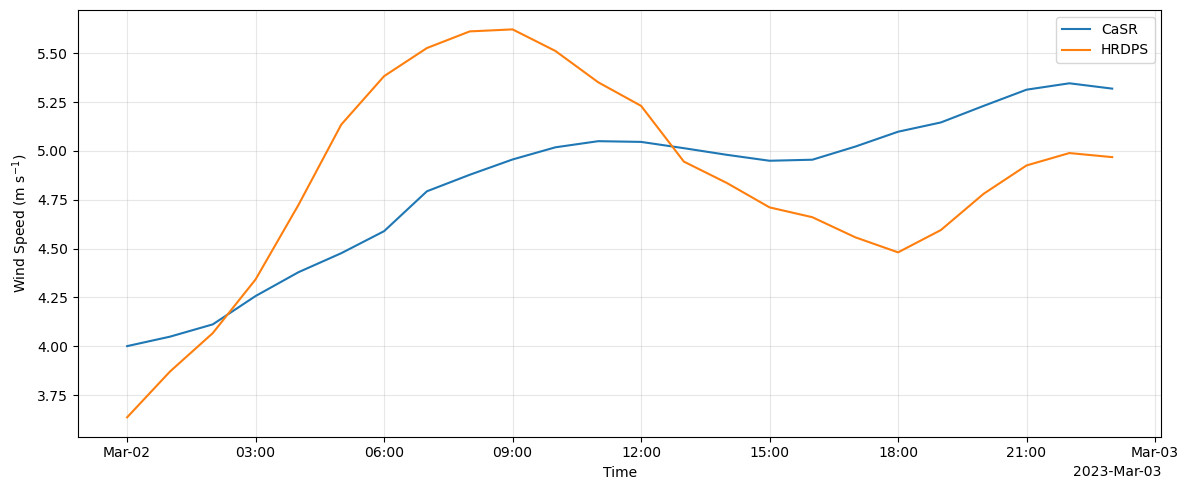

In [ ]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

mean_CaSR.plot(
    ax=ax,
    label='CaSR',
    linewidth=1.5
)

mean_HRDPS.plot(
    ax=ax,
    label='HRDPS',
    linewidth=1.5
)

ax.set_xlabel('Time')
ax.set_ylabel('Spatially Mean Wind Speed (m s$^{-1}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


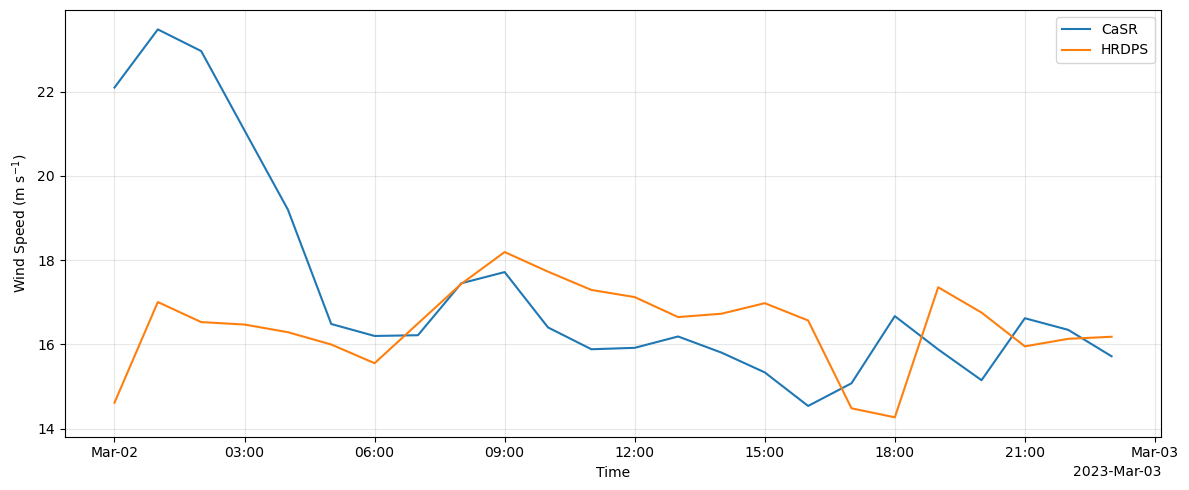

In [8]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

max_CaSR.plot(
    ax=ax,
    label='CaSR',
    linewidth=1.5
)

max_HRDPS.plot(
    ax=ax,
    label='HRDPS',
    linewidth=1.5
)

ax.set_xlabel('Time')
ax.set_ylabel('Wind Speed (m s$^{-1}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [39]:
# find a grid in the north 

import xarray as xr
import numpy as np

# path
path_base_CaSR = '/ocean/jqiu/forcings/CaSR/CaSR_'
path_base_HRDPS = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_'
path_date = 'y2023m03d02'
path_tail = '.nc'

path_CaSR = path_base_CaSR + path_date + path_tail
path_HRDPS = path_base_HRDPS + path_date + path_tail

# read files
ds_CaSR = xr.open_dataset(path_CaSR)
ds_HRDPS = xr.open_dataset(path_HRDPS)


def find_nearest_grid_point(ds, target_lon, target_lat, dataset_name):
    """
    找到二维 nav_lon/nav_lat 网格中距离目标经纬度最近的格点。
    返回并打印格点索引 (y, x)、实际经纬度和距离。
    """

    lon = ds['nav_lon'].values
    lat = ds['nav_lat'].values

    # 将目标经度转换到与数据相同的经度范围
    # 数据经度为 [-180, 180] 时，将 305 转换为 -55
    if np.nanmin(lon) < 0:
        target_lon_used = (target_lon + 180) % 360 - 180
    else:
        target_lon_used = target_lon % 360

    # Haversine公式：计算球面距离
    lon_rad = np.deg2rad(lon)
    lat_rad = np.deg2rad(lat)
    target_lon_rad = np.deg2rad(target_lon_used)
    target_lat_rad = np.deg2rad(target_lat)

    delta_lon = lon_rad - target_lon_rad
    delta_lat = lat_rad - target_lat_rad

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(target_lat_rad)
        * np.cos(lat_rad)
        * np.sin(delta_lon / 2) ** 2
    )

    # 防止浮点误差导致 a 略微超过 [0, 1]
    a = np.clip(a, 0, 1)

    earth_radius_km = 6371.0
    distance_km = 2 * earth_radius_km * np.arcsin(np.sqrt(a))

    # 忽略缺失值，寻找最近格点
    flat_index = np.nanargmin(distance_km)
    y_index, x_index = np.unravel_index(flat_index, distance_km.shape)

    print(f'\n{dataset_name}:')
    print(f'  target lon/lat = ({target_lon_used:.6f}, {target_lat:.6f})')
    print(f'  nearest grid index: y = {y_index}, x = {x_index}')
    print(
        f'  nearest grid lon/lat = '
        f'({lon[y_index, x_index]:.6f}, {lat[y_index, x_index]:.6f})'
    )
    print(f'  distance = {distance_km[y_index, x_index]:.3f} km')

    return y_index, x_index


# 目标位置
target_lon = 125 + 180   # 305°，等价于 -55°
target_lat = 50

y_CaSR, x_CaSR = find_nearest_grid_point(
    ds_CaSR,
    target_lon,
    target_lat,
    'CaSR'
)

y_HRDPS, x_HRDPS = find_nearest_grid_point(
    ds_HRDPS,
    target_lon,
    target_lat,
    'HRDPS'
)


CaSR:
  target lon/lat = (305.000000, 50.000000)
  nearest grid index: y = 79, x = 69
  nearest grid lon/lat = (239.697571, 52.440727)
  distance = 4398.656 km

HRDPS:
  target lon/lat = (305.000000, 50.000000)
  nearest grid index: y = 229, x = 189
  nearest grid lon/lat = (239.130432, 51.770148)
  distance = 4464.386 km


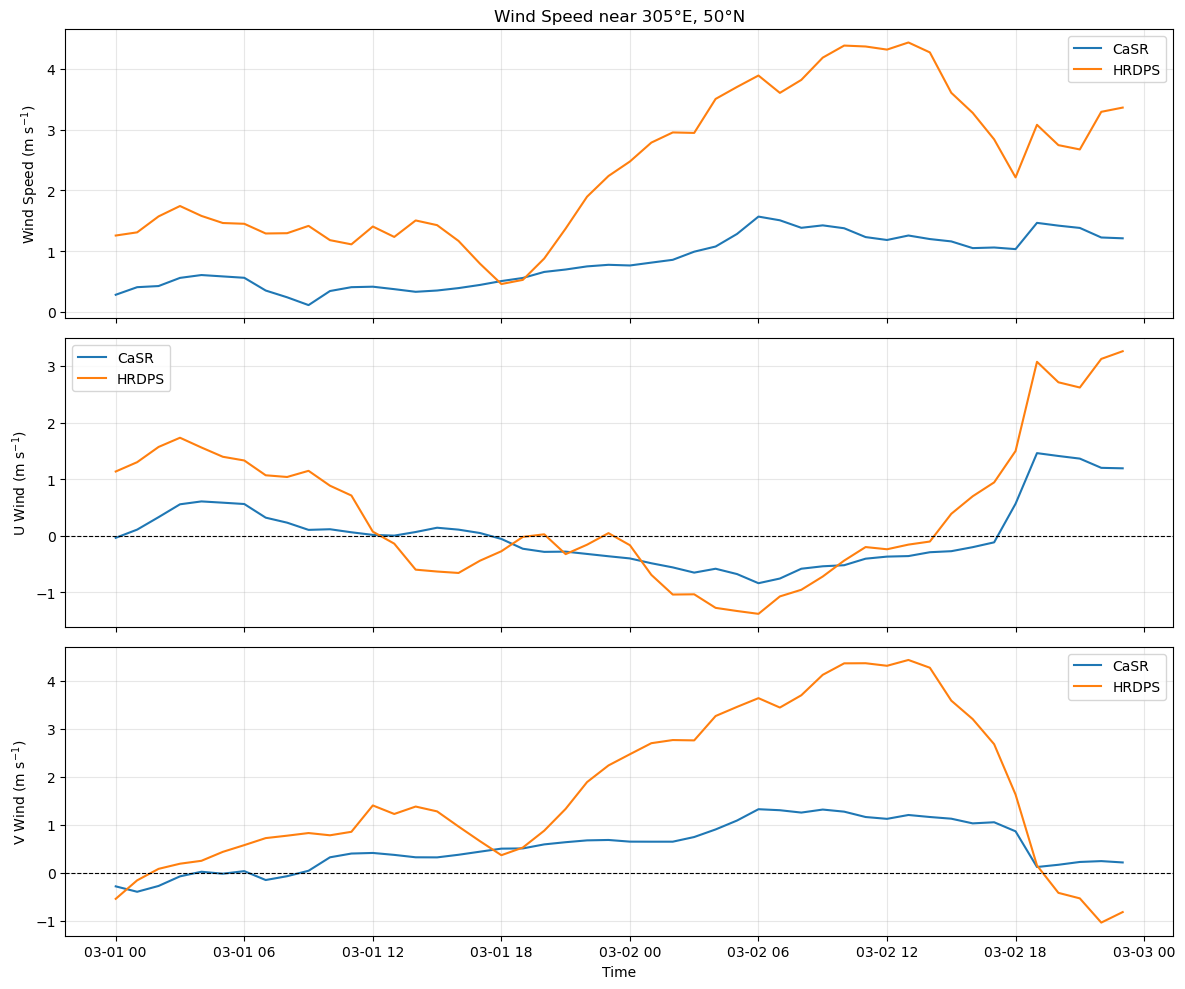

In [41]:
# visualize the north

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# paths
# ============================================================

path_CaSR_0301 = (
    '/ocean/jqiu/forcings/CaSR/CaSR_y2023m03d01.nc'
)
path_CaSR_0302 = (
    '/ocean/jqiu/forcings/CaSR/CaSR_y2023m03d02.nc'
)

path_HRDPS_0301 = (
    '/results/forcing/atmospheric/continental2.5/'
    'nemo_forcing/hrdps_y2023m03d01.nc'
)
path_HRDPS_0302 = (
    '/results/forcing/atmospheric/continental2.5/'
    'nemo_forcing/hrdps_y2023m03d02.nc'
)


# ============================================================
# read files separately
# ============================================================

ds_CaSR_0301 = xr.open_dataset(path_CaSR_0301)
ds_CaSR_0302 = xr.open_dataset(path_CaSR_0302)

ds_HRDPS_0301 = xr.open_dataset(path_HRDPS_0301)
ds_HRDPS_0302 = xr.open_dataset(path_HRDPS_0302)


# ============================================================
# extract u and v at selected grid points
# ============================================================

# CaSR: y=79, x=69
u_CaSR_0301 = ds_CaSR_0301['u_wind'].isel(
    y=79, x=69
).values.squeeze()

v_CaSR_0301 = ds_CaSR_0301['v_wind'].isel(
    y=79, x=69
).values.squeeze()

u_CaSR_0302 = ds_CaSR_0302['u_wind'].isel(
    y=79, x=69
).values.squeeze()

v_CaSR_0302 = ds_CaSR_0302['v_wind'].isel(
    y=79, x=69
).values.squeeze()


# HRDPS: y=229, x=189
u_HRDPS_0301 = ds_HRDPS_0301['u_wind'].isel(
    y=229, x=189
).values.squeeze()

v_HRDPS_0301 = ds_HRDPS_0301['v_wind'].isel(
    y=229, x=189
).values.squeeze()

u_HRDPS_0302 = ds_HRDPS_0302['u_wind'].isel(
    y=229, x=189
).values.squeeze()

v_HRDPS_0302 = ds_HRDPS_0302['v_wind'].isel(
    y=229, x=189
).values.squeeze()


# ============================================================
# concatenate two days
# ============================================================

u_CaSR = np.concatenate([
    u_CaSR_0301,
    u_CaSR_0302
])

v_CaSR = np.concatenate([
    v_CaSR_0301,
    v_CaSR_0302
])

u_HRDPS = np.concatenate([
    u_HRDPS_0301,
    u_HRDPS_0302
])

v_HRDPS = np.concatenate([
    v_HRDPS_0301,
    v_HRDPS_0302
])


# calculate total wind speed
wind_CaSR = np.sqrt(u_CaSR**2 + v_CaSR**2)
wind_HRDPS = np.sqrt(u_HRDPS**2 + v_HRDPS**2)


# ============================================================
# concatenate time
# ============================================================

time_CaSR = np.concatenate([
    ds_CaSR_0301['time_counter'].values,
    ds_CaSR_0302['time_counter'].values
]).squeeze()

time_HRDPS = np.concatenate([
    ds_HRDPS_0301['time_counter'].values,
    ds_HRDPS_0302['time_counter'].values
]).squeeze()


# ============================================================
# plot
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 10),
    sharex=True
)


# total wind speed
axes[0].plot(
    time_CaSR,
    wind_CaSR,
    label='CaSR',
    linewidth=1.5
)

axes[0].plot(
    time_HRDPS,
    wind_HRDPS,
    label='HRDPS',
    linewidth=1.5
)

axes[0].set_ylabel('Wind Speed (m s$^{-1}$)')
axes[0].set_title('Wind Speed near 305°E, 50°N')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# u wind
axes[1].plot(
    time_CaSR,
    u_CaSR,
    label='CaSR',
    linewidth=1.5
)

axes[1].plot(
    time_HRDPS,
    u_HRDPS,
    label='HRDPS',
    linewidth=1.5
)

axes[1].axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=0.8
)

axes[1].set_ylabel('U Wind (m s$^{-1}$)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# v wind
axes[2].plot(
    time_CaSR,
    v_CaSR,
    label='CaSR',
    linewidth=1.5
)

axes[2].plot(
    time_HRDPS,
    v_HRDPS,
    label='HRDPS',
    linewidth=1.5
)

axes[2].axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=0.8
)

axes[2].set_xlabel('Time')
axes[2].set_ylabel('V Wind (m s$^{-1}$)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

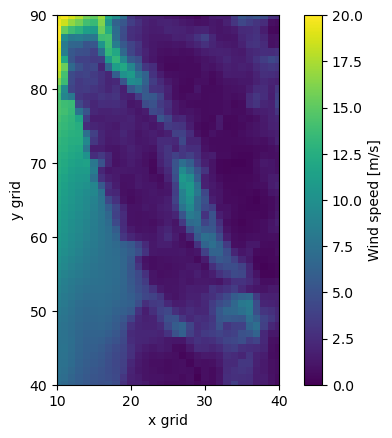

In [14]:
# CaSR pcolor 

speed_min=0
speed_max=20

plt.imshow(wind_CaSR.isel(time_counter=1).squeeze(), origin="lower",vmin=speed_min,vmax=speed_max)
plt.xlim(10, 40)   # 显示的 x 格点范围
plt.ylim(40, 90)   # 显示的 y 格点范围
plt.colorbar(label="Wind speed [m/s]")
plt.xlabel("x grid")
plt.ylabel("y grid")
plt.show()

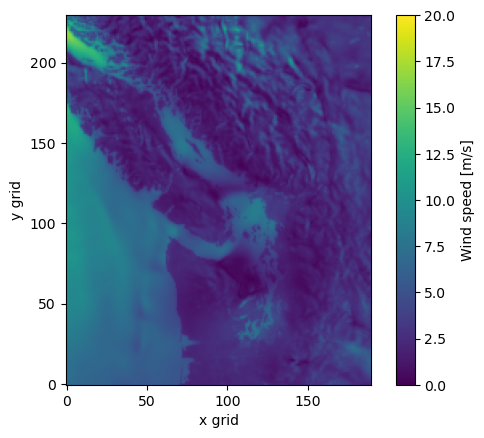

In [15]:
# HRDPS pcolor 

plt.imshow(wind_HRDPS.isel(time_counter=1).squeeze(), origin="lower",vmin=speed_min,vmax=speed_max)
plt.colorbar(label="Wind speed [m/s]")
plt.xlabel("x grid")
plt.ylabel("y grid")
plt.show()

### Temperature

In [2]:
# path and read in data

# path

path_base_CaSR='/ocean/jqiu/forcings/CaSR/CaSR_'
path_base_HRDPS='/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_'
path_date='y2023m03d02'
path_tail='.nc'

path_CaSR=path_base_CaSR+path_date+path_tail
path_HRDPS=path_base_HRDPS+path_date+path_tail

# read in file

import xarray as xr
import numpy as np

ds_CaSR=xr.open_dataset(path_CaSR)
ds_HRDPS=xr.open_dataset(path_HRDPS)

In [4]:
print(ds_CaSR)

<xarray.Dataset> Size: 6MB
Dimensions:       (time_counter: 24, y: 105, x: 70)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 192B 2023-03-02 ... 2023-03-0...
  * y             (y) int32 420B 0 1 2 3 4 5 6 7 ... 98 99 100 101 102 103 104
  * x             (x) int32 280B 0 1 2 3 4 5 6 7 8 ... 62 63 64 65 66 67 68 69
    nav_lat       (y, x) float32 29kB ...
    nav_lon       (y, x) float32 29kB ...
Data variables:
    solar         (time_counter, y, x) float32 706kB ...
    precip        (time_counter, y, x) float32 706kB ...
    therm_rad     (time_counter, y, x) float32 706kB ...
    tair          (time_counter, y, x) float32 706kB ...
    qair          (time_counter, y, x) float32 706kB ...
    u_wind        (time_counter, y, x) float32 706kB ...
    atmpres       (time_counter, y, x) float32 706kB ...
    v_wind        (time_counter, y, x) float32 706kB ...
    percentcloud  (time_counter, y, x) float32 706kB ...
Attributes:
    title:           Converted CaSR atmosphe

In [5]:
# extract temperature

temp_CaSR=ds_CaSR['tair']
mean_temp_CaSR=temp_CaSR.mean(dim=('y','x'),skipna=True)

temp_HRDPS=ds_HRDPS['tair']
mean_temp_HRDPS=temp_HRDPS.mean(dim=('y','x'),skipna=True)

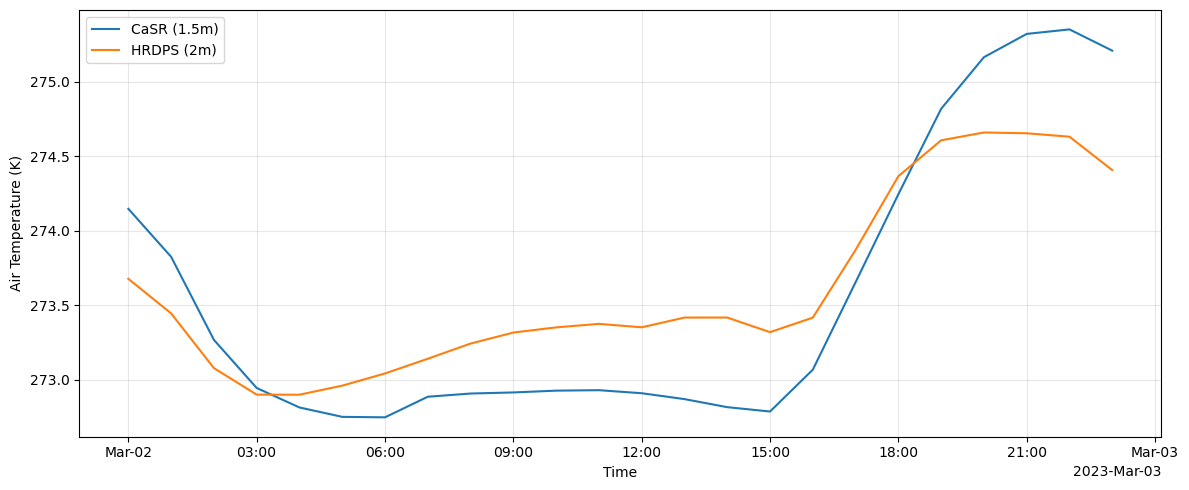

In [8]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

mean_temp_CaSR.plot(
    ax=ax,
    label='CaSR (1.5m)',
    linewidth=1.5
)

mean_temp_HRDPS.plot(
    ax=ax,
    label='HRDPS (2m)',
    linewidth=1.5
)

ax.set_xlabel('Time')
ax.set_ylabel('Air Temperature (K)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Solar Radiation

In [17]:
# path and read in data

# path

path_base_CaSR='/ocean/jqiu/forcings/CaSR/CaSR_'
path_base_HRDPS='/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_'
path_date='y2023m03d02'
path_tail='.nc'

path_CaSR=path_base_CaSR+path_date+path_tail
path_HRDPS=path_base_HRDPS+path_date+path_tail

# read in file

import xarray as xr
import numpy as np

ds_CaSR=xr.open_dataset(path_CaSR)
ds_HRDPS=xr.open_dataset(path_HRDPS)

# extract solar radiation

solar_CaSR=ds_CaSR['solar']
mean_solar_CaSR=solar_CaSR.mean(dim=('y','x'),skipna=True)

solar_HRDPS=ds_HRDPS['solar']
mean_solar_HRDPS=solar_HRDPS.mean(dim=('y','x'),skipna=True)



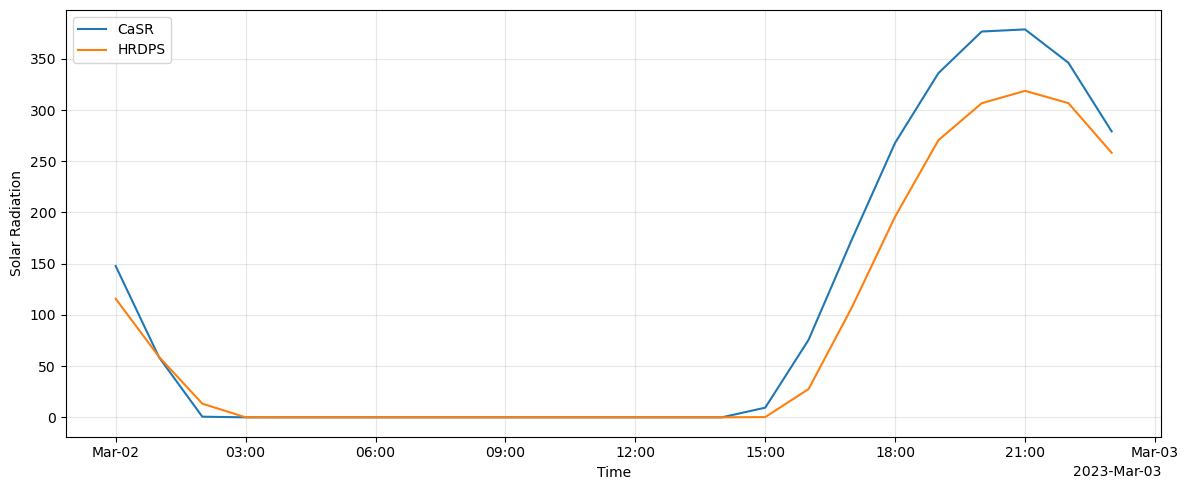

In [19]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

mean_solar_CaSR.plot(
    ax=ax,
    label='CaSR',
    linewidth=1.5
)

mean_solar_HRDPS.plot(
    ax=ax,
    label='HRDPS',
    linewidth=1.5
)

ax.set_xlabel('Time')
ax.set_ylabel('Solar Radiation')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Other Variables

In [28]:
import netCDF4 as nc
import numpy as np

# Define file paths
path_CaSR = '/ocean/jqiu/forcings/CaSR/CaSR_y2023m03d02.nc'
path_HRDPS = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2023m03d02.nc'

# Target variables for comparison
TARGET_VARS = [
    'time_counter', 'x', 'y', 
    'nav_lat', 'nav_lon', 
    'atmpres', 'percentcloud', 'precip', 
    'qair', 'solar', 'tair', 
    'therm_rad', 'u_wind', 'v_wind'
]

def get_var_info(dataset, var_name):
    """Extract attributes and sample data for a single variable, returning a dictionary."""
    if var_name not in dataset.variables:
        return {"shape": "Missing", "type": "Missing", "units": "Missing", "sample": "Missing"}
    
    var_obj = dataset.variables[var_name]
    info = {
        "shape": str(var_obj.shape),
        "type": str(var_obj.datatype),
        "units": getattr(var_obj, 'units', 'None')  # Display "None" if units attribute is missing
    }
    
    # Safely read a small amount of sample data
    if np.prod(var_obj.shape) > 0:
        try:
            if len(var_obj.shape) == 1:
                sample = var_obj[:3]
            elif len(var_obj.shape) == 2:
                sample = var_obj[0, :3]
            elif len(var_obj.shape) == 3:
                sample = var_obj[0, 0, :3]
            elif len(var_obj.shape) == 4:
                sample = var_obj[0, 0, 0, :3]
            else:
                sample = var_obj[...].flatten()[:3]
            
            # Format array: truncate floats to avoid long strings, take first 3 values
            if sample.dtype.kind == 'f':
                sample_str = "[" + ", ".join([f"{val:.6g}" for val in sample]) + ", ...]"
            else:
                sample_str = "[" + ", ".join([str(val) for val in sample]) + ", ...]"
                
            info["sample"] = sample_str
        except Exception:
            info["sample"] = "Read Error"
    else:
        info["sample"] = "Empty Array"
        
    return info

def compare_nc_files_as_table(file1, file2, vars_to_check):
    print("\nOpening files for side-by-side comparison...")
    try:
        ds1 = nc.Dataset(file1, 'r')
        ds2 = nc.Dataset(file2, 'r')
    except Exception as e:
        print(f"Failed to open files: {e}")
        return
    
    # Set table column widths
    col1_w = 14  # Variable Name
    col2_w = 10  # Attribute
    col3_w = 36  # File 1 Data
    col4_w = 36  # File 2 Data
    
    # Print table header
    sep_line = "-" * (col1_w + col2_w + col3_w + col4_w + 13)
    print(sep_line)
    print(f"| {'Variable':<{col1_w}} | {'Attribute':<{col2_w}} | {'CaSR (File 1)':<{col3_w}} | {'HRDPS (File 2)':<{col4_w}} |")
    print(sep_line)
    
    # Iterate through and compare each variable
    for var in vars_to_check:
        info1 = get_var_info(ds1, var)
        info2 = get_var_info(ds2, var)
        
        # First row: Variable Name and Shape
        print(f"| {var:<{col1_w}} | {'Shape':<{col2_w}} | {info1['shape']:<{col3_w}} | {info2['shape']:<{col4_w}} |")
        # Subsequent rows: Type, Units, Sample (Variable column left blank for clean look)
        print(f"| {'':<{col1_w}} | {'Type':<{col2_w}} | {info1['type']:<{col3_w}} | {info2['type']:<{col4_w}} |")
        print(f"| {'':<{col1_w}} | {'Units':<{col2_w}} | {info1['units']:<{col3_w}} | {info2['units']:<{col4_w}} |")
        print(f"| {'':<{col1_w}} | {'Sample':<{col2_w}} | {info1['sample']:<{col3_w}} | {info2['sample']:<{col4_w}} |")
        print(sep_line)

    ds1.close()
    ds2.close()

# Execute comparison
compare_nc_files_as_table(path_CaSR, path_HRDPS, TARGET_VARS)


Opening files for side-by-side comparison...
-------------------------------------------------------------------------------------------------------------
| Variable       | Attribute  | CaSR (File 1)                        | HRDPS (File 2)                       |
-------------------------------------------------------------------------------------------------------------
| time_counter   | Shape      | (24,)                                | (24,)                                |
|                | Type       | float64                              | float64                              |
|                | Units      | seconds since 1970-01-01             | seconds since 1970-01-01             |
|                | Sample     | [1.67772e+09, 1.67772e+09, 1.67772e+09, ...] | [1.67772e+09, 1.67772e+09, 1.67772e+09, ...] |
-------------------------------------------------------------------------------------------------------------
| x              | Shape      | (70,)                     

## Surface Velocity

In [1]:
# path

path_CaSR_u='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
path_CaSR_v='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'



In [ ]:
# load data

import xarray as xr

ds_CaSR_u=xr.open_dataset(path_CaSR_u)
ds_CaSR_v=xr.open_dataset(path_CaSR_v)

print(ds_CaSR_u)

# print(ds_CaSR_v)

<xarray.Dataset> Size: 2GB
Dimensions:               (y: 898, x: 398, nvertex: 4, depthu: 40,
                           axis_nbounds: 2, time_counter: 33)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * depthu                (depthu) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 264B ...
  * time_counter          (time_counter) datetime64[ns] 264B 2023-03-01T00:30...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    depthu_bounds         (depthu, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 528B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 528B ...
    vozocrtx              (time_counter, depth

In [5]:
# calculate the surface speed

u_CaSR = ds_CaSR_u['vozocrtx'].isel(depthu=0).values

v_CaSR = ds_CaSR_v['vomecrty'].isel(depthv=0).values


In [6]:
import numpy as np

velocity_CaSR=np.sqrt(u_CaSR**2+v_CaSR**2)

In [9]:
# find the maximum

idx = np.unravel_index(
    np.nanargmax(velocity_CaSR),
    velocity_CaSR.shape
)

time_idx, y_idx, x_idx = idx

print("Maximum Speed：", velocity_CaSR[idx])
print("Grid Location (y, x)：", y_idx, x_idx)
print("Time Step：", time_idx)

Maximum Speed： 8.331598
Grid Location (y, x)： 867 70
Time Step： 32


### Time Series



In [12]:
velocity_point=velocity_CaSR[:,867,70]

u_point=u_CaSR[:,867,70]

v_point=v_CaSR[:,867,70]

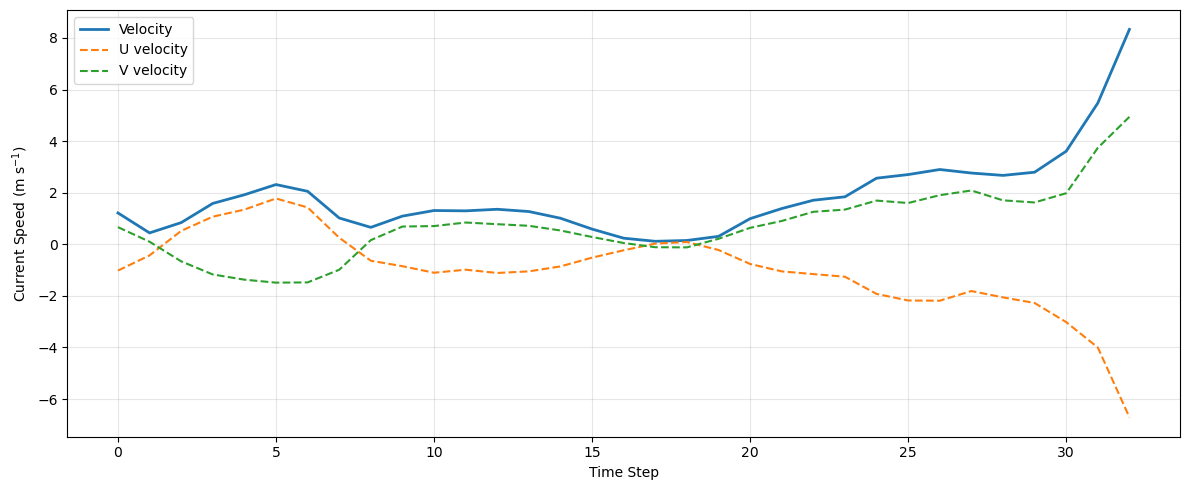

In [16]:
# visualization

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(velocity_point,
    label='Velocity',
    linewidth=2
)

ax.plot(u_point,
    label='U velocity',
    linestyle='--',
    linewidth=1.5
)


ax.plot(v_point,
    label='V velocity',
    linestyle='--',
    linewidth=1.5
)

ax.set_xlabel('Time Step')
ax.set_ylabel('Current Speed (m s$^{-1}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# HRDPS outputs vs CaSR outputs

# path

path_CaSR_u='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
path_CaSR_v='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'

date_dir_1 = "01mar23"
date_file_1 = "20230301"

date_dir_2 = "02mar23"
date_file_2 = "20230302"

hrdps_dir_1 = f"/results2/SalishSea/nowcast-green.202111/{date_dir_1}"
hrdps_dir_2 = f"/results2/SalishSea/nowcast-green.202111/{date_dir_2}"


hrdps_u_path_1 = f"{hrdps_dir_1}/SalishSea_1h_{date_file_1}_{date_file_1}_grid_U.nc"
hrdps_v_path_1 = f"{hrdps_dir_1}/SalishSea_1h_{date_file_1}_{date_file_1}_grid_V.nc"

hrdps_u_path_2 = f"{hrdps_dir_2}/SalishSea_1h_{date_file_2}_{date_file_2}_grid_U.nc"
hrdps_v_path_2 = f"{hrdps_dir_2}/SalishSea_1h_{date_file_2}_{date_file_2}_grid_V.nc"

# load data

import xarray as xr

ds_CaSR_u=xr.open_dataset(path_CaSR_u)
ds_CaSR_v=xr.open_dataset(path_CaSR_v)

ds_HRDPS_u_1=xr.open_dataset(hrdps_u_path_1)
ds_HRDPS_v_1=xr.open_dataset(hrdps_v_path_1)

ds_HRDPS_u_2=xr.open_dataset(hrdps_u_path_2)
ds_HRDPS_v_2=xr.open_dataset(hrdps_v_path_2)

# calculate the surface speed

u_CaSR = ds_CaSR_u['vozocrtx'].isel(depthu=0).values

v_CaSR = ds_CaSR_v['vomecrty'].isel(depthv=0).values

u_HRDPS_1 = ds_HRDPS_u_1['vozocrtx'].isel(depthu=0).values

v_HRDPS_1 = ds_HRDPS_v_1['vomecrty'].isel(depthv=0).values

u_HRDPS_2 = ds_HRDPS_u_2['vozocrtx'].isel(depthu=0).values

v_HRDPS_2 = ds_HRDPS_v_2['vomecrty'].isel(depthv=0).values

import numpy as np

velocity_CaSR=np.sqrt(u_CaSR**2+v_CaSR**2)
velocity_HRDPS_1=np.sqrt(u_HRDPS_1**2+v_HRDPS_1**2)
velocity_HRDPS_2=np.sqrt(u_HRDPS_2**2+v_HRDPS_2**2)

velocity_point_CaSR=velocity_CaSR[:,867,70]
velocity_point_HRDPS_1=velocity_HRDPS_1[:,867,70]
velocity_point_HRDPS_2=velocity_HRDPS_2[:,867,70]

velocity_point_HRDPS=np.concatenate((velocity_point_HRDPS_1,velocity_point_HRDPS_2))


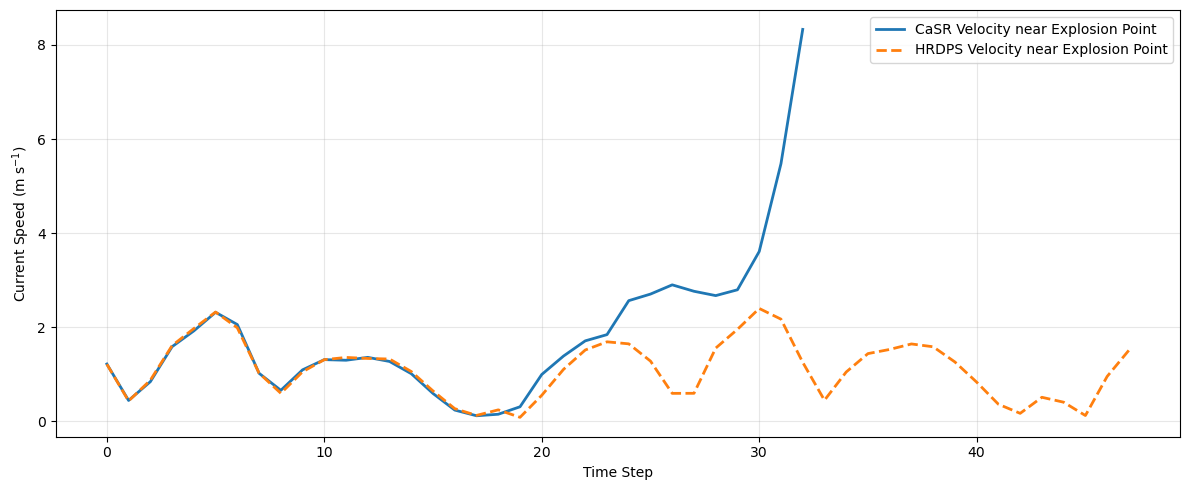

In [8]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(velocity_point_CaSR,
    label='CaSR Velocity near Explosion Point',
    linewidth=2
)

ax.plot(velocity_point_HRDPS,
    label='HRDPS Velocity near Explosion Point',
    linestyle='--',
    linewidth=2
)




ax.set_xlabel('Time Step')
ax.set_ylabel('Current Speed (m s$^{-1}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Field

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt



# ---------------------------------------------------------
# Paths 
# ---------------------------------------------------------

date_dir = "02mar23"
date_file = "20230302"

casr_dir = f"/ocean/jqiu/results/CaSR/{date_dir}"
hrdps_dir = f"/results2/SalishSea/nowcast-green.202111/{date_dir}"

casr_u_path = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
casr_v_path = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'


hrdps_u_path = f"{hrdps_dir}/SalishSea_1h_{date_file}_{date_file}_grid_U.nc"
hrdps_v_path = f"{hrdps_dir}/SalishSea_1h_{date_file}_{date_file}_grid_V.nc"

variable_u='vozocrtx'
variable_v='vomecrty'

# Plot every 8th model point
quiver_stride = 8

In [23]:
# load data

CaSR_u=xr.open_dataset(casr_u_path)
CaSR_u=CaSR_u[variable_u].isel(time_counter=32,depthu=0)
CaSR_v=xr.open_dataset(casr_v_path)
CaSR_v=CaSR_v[variable_v].isel(time_counter=32,depthv=0)

HRDPS_u=xr.open_dataset(hrdps_u_path)
HRDPS_u=HRDPS_u[variable_u].isel(time_counter=7,depthu=0)
HRDPS_v=xr.open_dataset(hrdps_v_path)
HRDPS_v=HRDPS_v[variable_v].isel(time_counter=7,depthv=0)

# calculate the difference

difference_u=CaSR_u-HRDPS_u
difference_v=CaSR_v-HRDPS_v

CaSR_speed = np.hypot(CaSR_u, CaSR_v)
HRDPS_speed = np.hypot(HRDPS_u, HRDPS_v)

difference_speed = np.hypot(difference_u,difference_v)

# grid

nj, ni = CaSR_u.shape

i_grid, j_grid = np.meshgrid(np.arange(ni),np.arange(nj))

s = np.s_[::quiver_stride, ::quiver_stride]

i_q = i_grid[s]
j_q = j_grid[s]


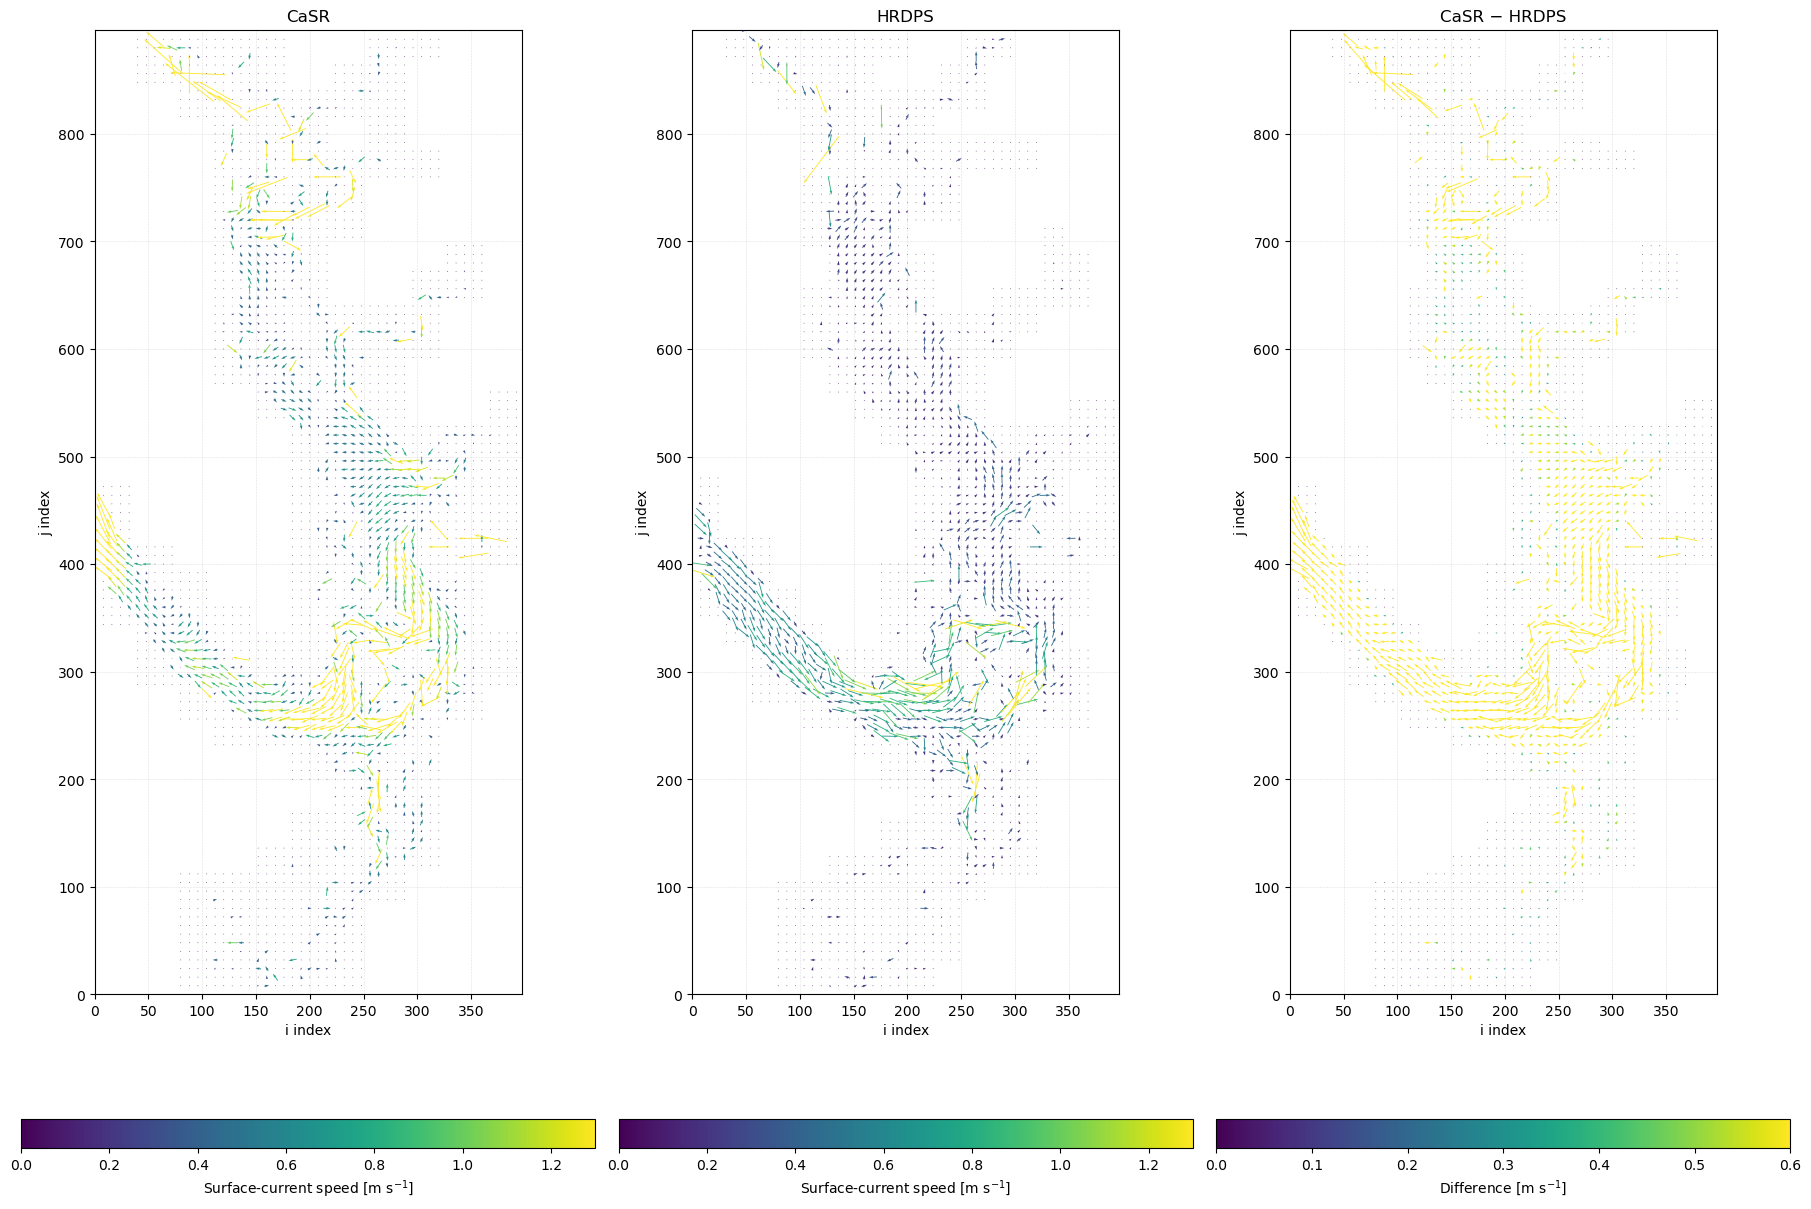

In [26]:

# Visualize 

speed_lim=(0,1.3)
difference_lim=(0,0.6)

fields = [
    (
        CaSR_u[s],
        CaSR_v[s],
        CaSR_speed[s],
        speed_lim,
        "CaSR",
        "Surface-current speed [m s$^{-1}$]",
    ),
    (
        HRDPS_u[s],
        HRDPS_v[s],
        HRDPS_speed[s],
        speed_lim,
        "HRDPS",
        "Surface-current speed [m s$^{-1}$]",
    ),
    (
        difference_u[s],
        difference_v[s],
        difference_speed[s],
        difference_lim,
        "CaSR − HRDPS",
        "Difference [m s$^{-1}$]",
    ),
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 12),
    constrained_layout=True,
)

for ax, (
    u,
    v,
    magnitude,
    limits,
    title,
    colorbar_label,
) in zip(axes, fields):

    q = ax.quiver(
        i_q,
        j_q,
        u,
        v,
        magnitude,
        angles="xy",
        scale_units="xy",
        scale=None,
        cmap="viridis",
        clim=limits,
        width=0.002,
        pivot="middle",
    )

    ax.set_title(title)

    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

    ax.set_xlim(0, ni - 1)
    ax.set_ylim(0, nj - 1)

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.grid(
        linestyle="--",
        linewidth=0.4,
        alpha=0.4,
    )

    colorbar = fig.colorbar(
        q,
        ax=ax,
        orientation="horizontal",
        pad=0.08,
        fraction=0.05,
    )

    colorbar.set_label(colorbar_label)




plt.show()

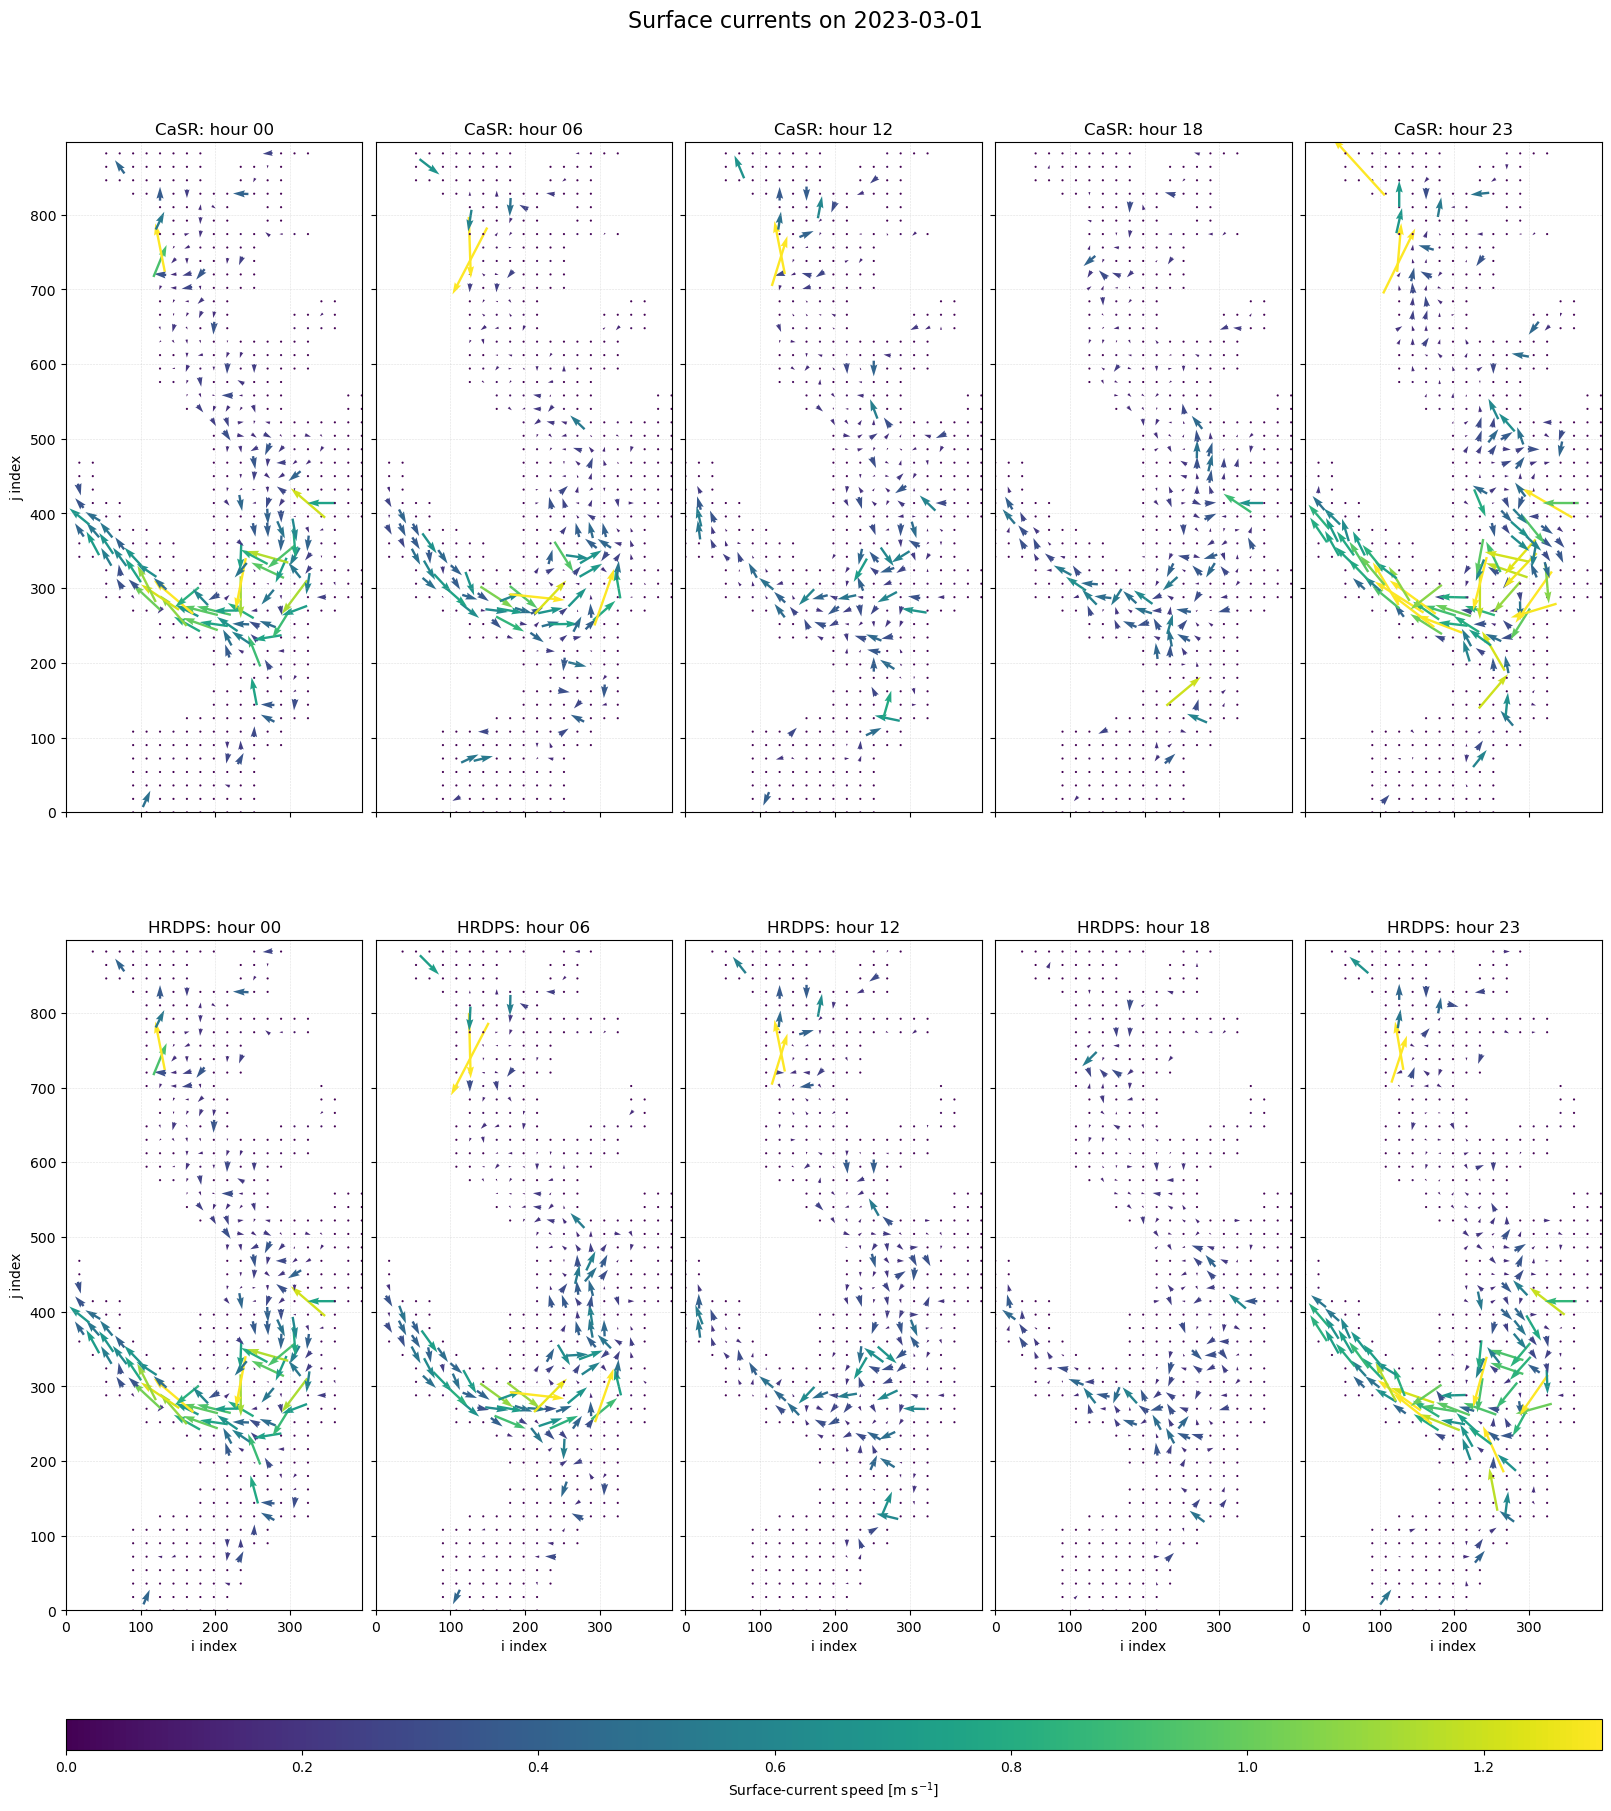

In [ ]:
# Vector plot of different time steps

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# ---------------------------------------------------------
# Paths and settings
# ---------------------------------------------------------

date_dir = "01mar23"
date_file = "20230301"

casr_u_path = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_U.nc"
)
casr_v_path = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_V.nc"
)

hrdps_dir = f"/results2/SalishSea/nowcast-green.202111/{date_dir}"

hrdps_u_path = (
    f"{hrdps_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_U.nc"
)
hrdps_v_path = (
    f"{hrdps_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_V.nc"
)

variable_u = "vozocrtx"
variable_v = "vomecrty"

# Time indices to plot
time_indices = [0, 6, 12, 18, 23]

# Plot every 16th model point
quiver_stride = 18

# Shared colour limits
speed_lim = (0.0, 1.3)

# Shared arrow scaling.
# Increase this value to make arrows shorter.
quiver_scale = 0.02


# ---------------------------------------------------------
# Open datasets
# ---------------------------------------------------------

casr_u_ds = xr.open_dataset(casr_u_path)
casr_v_ds = xr.open_dataset(casr_v_path)

hrdps_u_ds = xr.open_dataset(hrdps_u_path)
hrdps_v_ds = xr.open_dataset(hrdps_v_path)


# Surface-current fields for the selected times
casr_u = casr_u_ds[variable_u].isel(
    time_counter=time_indices,
    depthu=0,
)

casr_v = casr_v_ds[variable_v].isel(
    time_counter=time_indices,
    depthv=0,
)

hrdps_u = hrdps_u_ds[variable_u].isel(
    time_counter=time_indices,
    depthu=0,
)

hrdps_v = hrdps_v_ds[variable_v].isel(
    time_counter=time_indices,
    depthv=0,
)


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------

nj, ni = casr_u.isel(time_counter=0).shape

i_grid, j_grid = np.meshgrid(
    np.arange(ni),
    np.arange(nj),
)

s = np.s_[::quiver_stride, ::quiver_stride]

i_q = i_grid[s]
j_q = j_grid[s]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(16, 18),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

norm = Normalize(
    vmin=speed_lim[0],
    vmax=speed_lim[1],
)

cmap = "viridis"

datasets = [
    ("CaSR", casr_u, casr_v),
    ("HRDPS", hrdps_u, hrdps_v),
]

quiver_for_colorbar = None

for row, (dataset_name, u_all, v_all) in enumerate(datasets):

    for col, time_index in enumerate(time_indices):

        ax = axes[row, col]

        u = u_all.isel(time_counter=col).values
        v = v_all.isel(time_counter=col).values

        speed = np.hypot(u, v)

        q = ax.quiver(
            i_q,
            j_q,
            u[s],
            v[s],
            speed[s],
            angles="xy",
            scale_units="xy",
            scale=quiver_scale,
            cmap=cmap,
            norm=norm,
            width=0.008,
            pivot="middle",
        )

        if quiver_for_colorbar is None:
            quiver_for_colorbar = q

        ax.set_title(
            f"{dataset_name}: time step {time_index:02d}",
            fontsize=12,
        )

        ax.set_xlim(0, ni - 1)
        ax.set_ylim(0, nj - 1)

        ax.set_aspect(
            "equal",
            adjustable="box",
        )

        ax.grid(
            linestyle="--",
            linewidth=0.4,
            alpha=0.4,
        )

        if row == 1:
            ax.set_xlabel("i index")

        if col == 0:
            ax.set_ylabel("j index")


# One shared colorbar for all 10 panels
colorbar = fig.colorbar(
    quiver_for_colorbar,
    ax=axes,
    orientation="horizontal",
    pad=0.04,
    fraction=0.04,
    aspect=50,
)

colorbar.set_label(
    "Surface-current speed [m s$^{-1}$]"
)

fig.suptitle(
    "Surface currents on 2023-03-01",
    fontsize=16,
)

plt.show()


# ---------------------------------------------------------
# Close datasets
# ---------------------------------------------------------

casr_u_ds.close()
casr_v_ds.close()
hrdps_u_ds.close()
hrdps_v_ds.close()

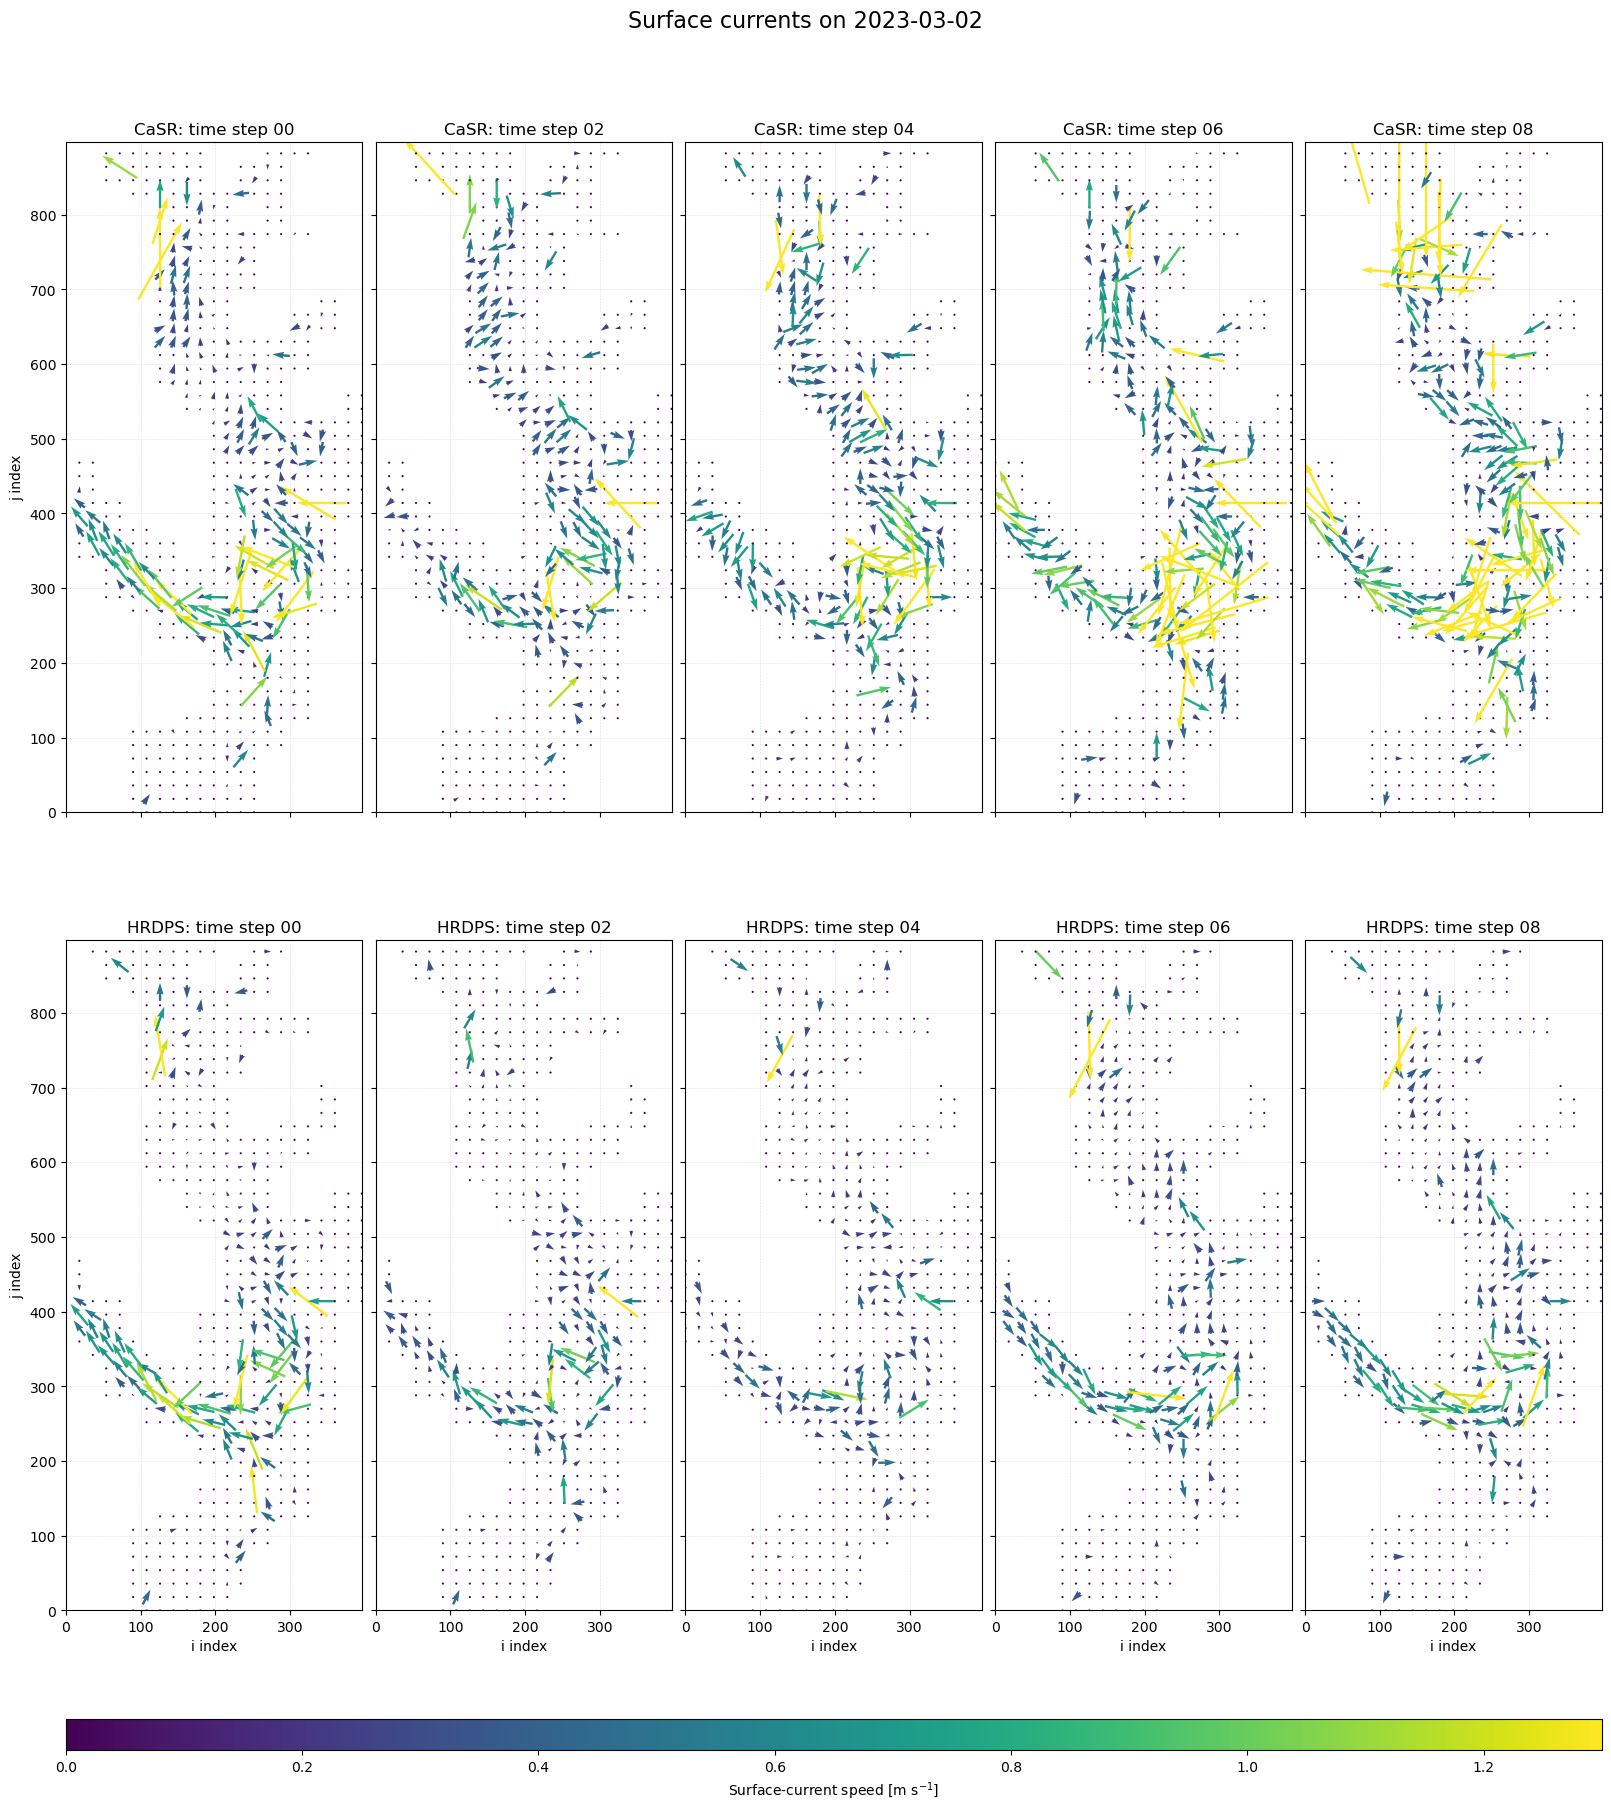

In [29]:
# Vector plot of different time steps

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# ---------------------------------------------------------
# Paths and settings
# ---------------------------------------------------------

date_dir = "02mar23"
date_file = "20230302"

casr_u_path = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_U.nc"
)
casr_v_path = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_V.nc"
)

hrdps_dir = f"/results2/SalishSea/nowcast-green.202111/{date_dir}"

hrdps_u_path = (
    f"{hrdps_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_U.nc"
)
hrdps_v_path = (
    f"{hrdps_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_V.nc"
)

variable_u = "vozocrtx"
variable_v = "vomecrty"

# CaSR is stored continuously from 2023-03-01
casr_time_indices = [24, 26, 28, 30, 32]

# HRDPS file starts at 2023-03-02
hrdps_time_indices = [0, 2, 4, 6, 8]

# Corresponding hours on 2023-03-02
plot_hours = [0, 2, 4, 6, 8]

# Plot every 18th model point
quiver_stride = 18

# Shared colour limits
speed_lim = (0.0, 1.3)

# Shared arrow scaling
quiver_scale = 0.02


# ---------------------------------------------------------
# Open datasets
# ---------------------------------------------------------

casr_u_ds = xr.open_dataset(casr_u_path)
casr_v_ds = xr.open_dataset(casr_v_path)

hrdps_u_ds = xr.open_dataset(hrdps_u_path)
hrdps_v_ds = xr.open_dataset(hrdps_v_path)


# ---------------------------------------------------------
# Select surface-current fields
# ---------------------------------------------------------

casr_u = casr_u_ds[variable_u].isel(
    time_counter=casr_time_indices,
    depthu=0,
)

casr_v = casr_v_ds[variable_v].isel(
    time_counter=casr_time_indices,
    depthv=0,
)

hrdps_u = hrdps_u_ds[variable_u].isel(
    time_counter=hrdps_time_indices,
    depthu=0,
)

hrdps_v = hrdps_v_ds[variable_v].isel(
    time_counter=hrdps_time_indices,
    depthv=0,
)


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------

nj, ni = casr_u.isel(time_counter=0).shape

i_grid, j_grid = np.meshgrid(
    np.arange(ni),
    np.arange(nj),
)

s = np.s_[::quiver_stride, ::quiver_stride]

i_q = i_grid[s]
j_q = j_grid[s]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(16, 18),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

norm = Normalize(
    vmin=speed_lim[0],
    vmax=speed_lim[1],
)

cmap = "viridis"

datasets = [
    ("CaSR", casr_u, casr_v),
    ("HRDPS", hrdps_u, hrdps_v),
]

quiver_for_colorbar = None

for row, (dataset_name, u_all, v_all) in enumerate(datasets):

    for col, hour in enumerate(plot_hours):

        ax = axes[row, col]

        # Because the desired time indices were already selected above,
        # col=0...4 corresponds to hours 00, 02, 04, 06, and 08.
        u = u_all.isel(time_counter=col).values
        v = v_all.isel(time_counter=col).values

        speed = np.hypot(u, v)

        q = ax.quiver(
            i_q,
            j_q,
            u[s],
            v[s],
            speed[s],
            angles="xy",
            scale_units="xy",
            scale=quiver_scale,
            cmap=cmap,
            norm=norm,
            width=0.008,
            pivot="middle",
        )

        if quiver_for_colorbar is None:
            quiver_for_colorbar = q

        ax.set_title(
            f"{dataset_name}: time step {hour:02d}",
            fontsize=12,
        )

        ax.set_xlim(0, ni - 1)
        ax.set_ylim(0, nj - 1)

        ax.set_aspect(
            "equal",
            adjustable="box",
        )

        ax.grid(
            linestyle="--",
            linewidth=0.4,
            alpha=0.4,
        )

        if row == 1:
            ax.set_xlabel("i index")

        if col == 0:
            ax.set_ylabel("j index")


# ---------------------------------------------------------
# Shared colorbar
# ---------------------------------------------------------

colorbar = fig.colorbar(
    quiver_for_colorbar,
    ax=axes,
    orientation="horizontal",
    pad=0.04,
    fraction=0.04,
    aspect=50,
)

colorbar.set_label(
    "Surface-current speed [m s$^{-1}$]"
)

fig.suptitle(
    "Surface currents on 2023-03-02",
    fontsize=16,
)

plt.show()


# ---------------------------------------------------------
# Close datasets
# ---------------------------------------------------------

casr_u_ds.close()
casr_v_ds.close()
hrdps_u_ds.close()
hrdps_v_ds.close()

## Surface Temperature


In [12]:
# HRDPS outputs vs CaSR outputs

# path

path_CaSR_t='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_T.nc'


date_dir_1 = "01mar23"
date_file_1 = "20230301"

date_dir_2 = "02mar23"
date_file_2 = "20230302"

hrdps_dir_1 = f"/results2/SalishSea/nowcast-green.202111/{date_dir_1}"
hrdps_dir_2 = f"/results2/SalishSea/nowcast-green.202111/{date_dir_2}"


hrdps_t_path_1 = f"{hrdps_dir_1}/SalishSea_1h_{date_file_1}_{date_file_1}_grid_T.nc"
hrdps_t_path_2 = f"{hrdps_dir_2}/SalishSea_1h_{date_file_2}_{date_file_2}_grid_T.nc"


# load data

import xarray as xr

ds_CaSR_t=xr.open_dataset(path_CaSR_t)


ds_HRDPS_t_1=xr.open_dataset(hrdps_t_path_1)
ds_HRDPS_t_2=xr.open_dataset(hrdps_t_path_2)


# calculate the surface speed

t_CaSR = ds_CaSR_t['votemper'].isel(deptht=0).values


t_HRDPS_1 = ds_HRDPS_t_1['votemper'].isel(deptht=0).values
t_HRDPS_2 = ds_HRDPS_t_2['votemper'].isel(deptht=0).values



import numpy as np



t_point_CaSR=t_CaSR[:,867,70]
t_point_HRDPS_1=t_HRDPS_1[:,867,70]
t_point_HRDPS_2=t_HRDPS_2[:,867,70]

t_point_HRDPS=np.concatenate((t_point_HRDPS_1,t_point_HRDPS_2))

<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1953779/1011330092.py:22: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Temperature ($^{\circ}$C)')


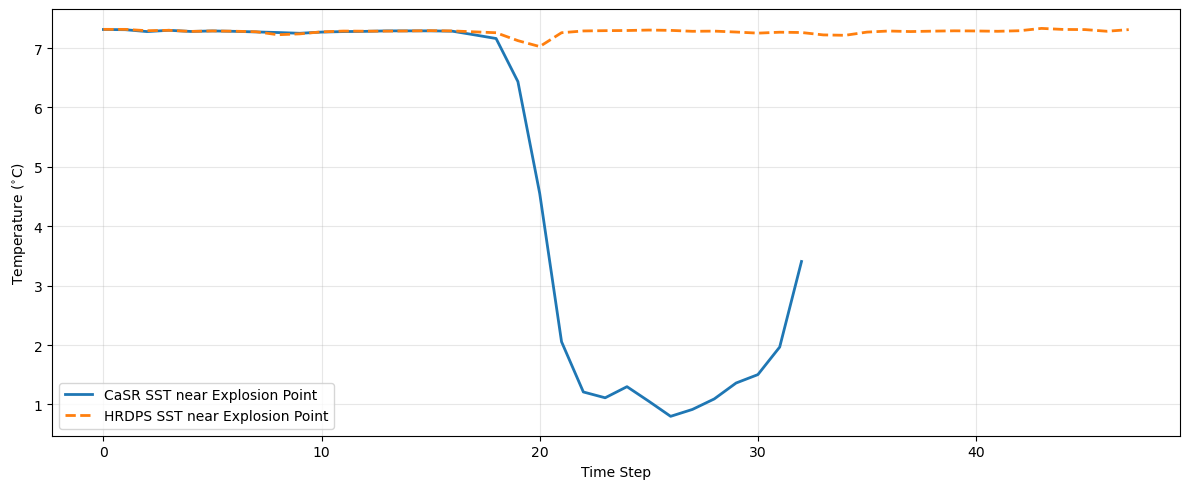

In [14]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t_point_CaSR,
    label='CaSR SST near Explosion Point',
    linewidth=2
)

ax.plot(t_point_HRDPS,
    label='HRDPS SST near Explosion Point',
    linestyle='--',
    linewidth=2
)




ax.set_xlabel('Time Step')
ax.set_ylabel('Temperature ($^{\circ}$C)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
